In [1]:
from modules.train import train_model
from modules.model import TumorClassifier
from modules.transforms import train_transform, val_transform, test_transform
from modules.metrics import evaluate_and_report
from modules.train2 import train_model2
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import cv2
import torch
from sklearn.preprocessing import LabelEncoder
from torchvision import datasets

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TumorClassifier()
model = model.to(device)

# Load dataset using ImageFolder
train_dataset = datasets.ImageFolder(root="brain_tumor_dataset/Training", transform=train_transform())

In [4]:
train_model2(
    model,
    train_dataset,
    batch_size=32,
    epochs=20,
    val_split=0.2,
    lr=0.001,
    save_path="./training_data/effnet_weights_sampler_cosine2.pth",
    use_mixup=True,
    scheduler_type="cosine",
)

Epoch 1/20 - Loss: 60.2113 - Train Acc: 0.5610 - Val Acc: 0.9756
Epoch 2/20 - Loss: 54.5556 - Train Acc: 0.5788 - Val Acc: 0.9774
Epoch 3/20 - Loss: 51.1531 - Train Acc: 0.6206 - Val Acc: 0.9547
Epoch 4/20 - Loss: 48.4806 - Train Acc: 0.6577 - Val Acc: 0.9721
Epoch 5/20 - Loss: 47.5508 - Train Acc: 0.6298 - Val Acc: 0.9652
Epoch 6/20 - Loss: 48.7178 - Train Acc: 0.6420 - Val Acc: 0.9913
Epoch 7/20 - Loss: 46.4662 - Train Acc: 0.7182 - Val Acc: 0.9686
Epoch 8/20 - Loss: 44.7968 - Train Acc: 0.6446 - Val Acc: 0.9895
Epoch 9/20 - Loss: 49.3655 - Train Acc: 0.6037 - Val Acc: 0.9878
Epoch 10/20 - Loss: 43.7401 - Train Acc: 0.6668 - Val Acc: 0.9930
Epoch 11/20 - Loss: 46.3972 - Train Acc: 0.6376 - Val Acc: 0.9913
Epoch 12/20 - Loss: 42.3983 - Train Acc: 0.5810 - Val Acc: 0.9861
Epoch 13/20 - Loss: 46.2782 - Train Acc: 0.6381 - Val Acc: 0.9913
Epoch 14/20 - Loss: 44.3516 - Train Acc: 0.6677 - Val Acc: 0.9930
Epoch 15/20 - Loss: 42.8643 - Train Acc: 0.5836 - Val Acc: 0.9930
Epoch 16/20 - Loss:

KeyboardInterrupt: 

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TumorClassifier()
model = model.to(device)
model.load_state_dict(torch.load("./training_data/effnet_weights_sampler_cosine2.pth"))
model.eval()  # Set the model to evaluation mode

TumorClassifier(
  (base_model): Sequential(
    (0): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_act

In [5]:
test_dataset = datasets.ImageFolder(root="brain_tumor_dataset/Testing", transform=val_transform())

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


=== Classification Report ===
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.26      0.41       100
meningioma_tumor       0.67      0.98      0.80       115
        no_tumor       0.75      0.97      0.85       105
 pituitary_tumor       1.00      0.86      0.93        74

        accuracy                           0.77       394
       macro avg       0.86      0.77      0.75       394
    weighted avg       0.84      0.77      0.74       394


=== Test Accuracy: 77.41% ===


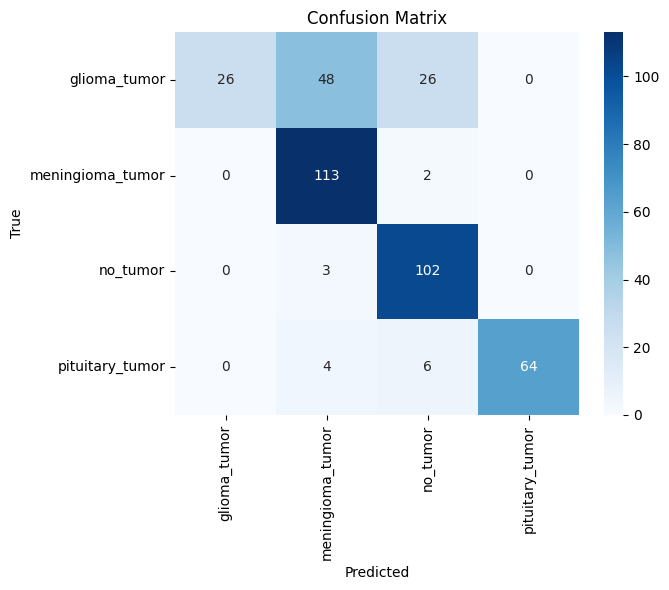

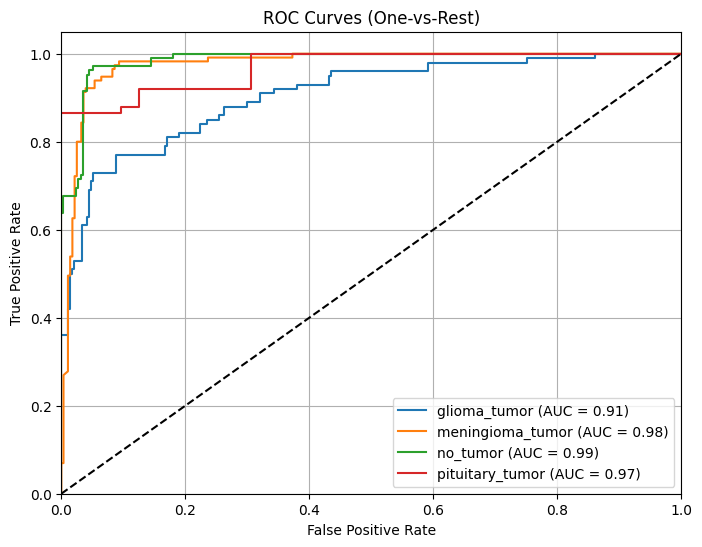

(array([2, 1, 1, 0, 0, 1, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1,
        1, 1, 2, 2, 0, 1, 1, 1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 1, 0, 2, 1, 1,
        1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2,
        1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [6]:
evaluate_and_report(
    model,
    test_loader,
    device,
    test_dataset.classes,
)